# Ejercicio 3: Predicción del consumo de energía eléctrica

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

## 1. Carga de datos

In [2]:
df = pd.read_csv('energia_data.csv')
df.head()

,Temperatura,Hora,Dia_Semana,Consumo_Energia
0,28.891805,1,1,401.990602
1,22.244071,2,2,334.846911
2,20.909006,3,3,326.926080
3,24.983128,4,4,383.016951
4,24.149077,5,5,388.748151


In [3]:
df.describe()

,Temperatura,Hora,Dia_Semana,Consumo_Energia
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,24.924793,12.493600,3.99940,400.043522
std,5.004022,6.921297,2.00005,63.825152
min,5.387999,1.000000,1.00000,185.196384
25%,21.578541,6.000000,2.00000,356.735276
50%,24.900520,12.000000,4.00000,399.270398
75%,28.310962,18.000000,6.00000,443.134098
max,44.631189,24.000000,7.00000,631.093191


## 2. Entrenamiento del modelo

In [4]:
X = df[['Temperatura', 'Hora', 'Dia_Semana']]
y = df['Consumo_Energia']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 9.95, 5.02,-3.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Temperatura','Hora','Dia_Semana']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,101.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## 3. Coeficientes y variable con mayor impacto

In [5]:
for var, coef in zip(X.columns, model.coef_):
    print(f'{var}: {coef:.4f}')
print('Intercepto:', model.intercept_)

Temperatura: 9.9529
Hora: 5.0198
Dia_Semana: -3.0312
Intercepto: 101.28823172887473


## 4. Evaluación del modelo

In [6]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 429.5187
RMSE: 20.7248
R2: 0.8968


## 5. Visualización de relaciones

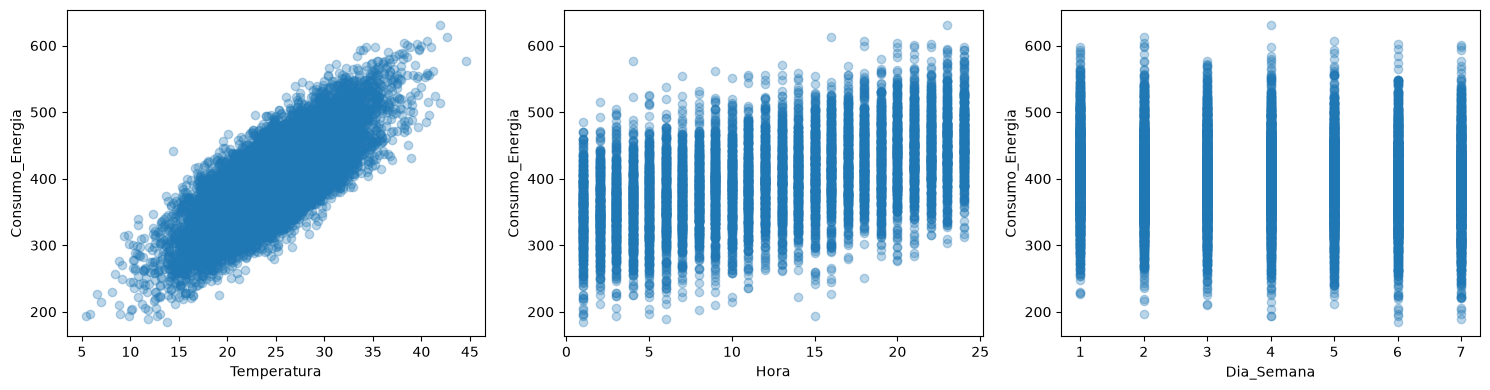

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, X.columns):
    ax.scatter(df[col], df['Consumo_Energia'], alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('Consumo_Energia')
plt.tight_layout()
plt.show()

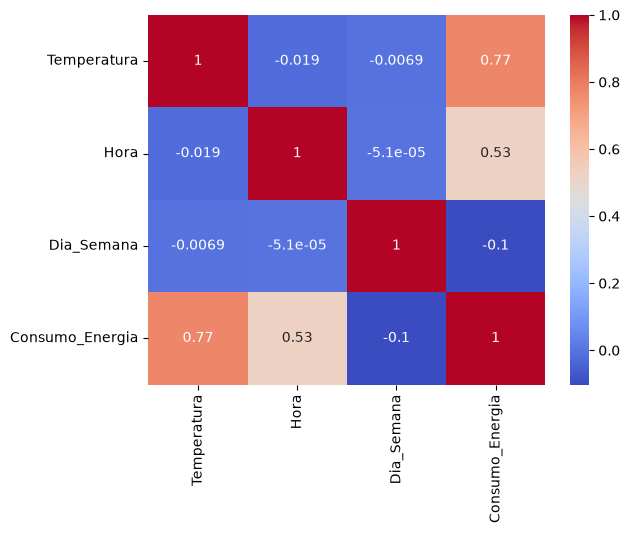

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## 6. Exportar modelo

In [9]:
joblib.dump(model, 'modelo_energia.joblib')

['modelo_energia.joblib']